# 📋 Ejercicio Clase 1 — Validación Temporal y Backtesting: No-Renovación de Auto
## Diplomado ML en Seguros · Subtema 4

---

## Contexto

**SeguraMax** entrenó un modelo GBM para predecir no-renovaciones **en 2021** y lo puso en producción. Desde entonces, el modelo lleva **3 años sin re-entrenarse**. El mercado cambió: los comparadores digitales hicieron trivial cambiar de aseguradora, y los incrementos de prima — que antes retenían clientes — ahora los expulsan.

El director de Retención pregunta: *"¿Nuestro modelo sigue siendo válido? ¿Cuánto valor habría generado? ¿Vale la pena re-entrenarlo?"*

Tu trabajo responde esas tres preguntas.

---

## Lo que practicarás

| Parte | Concepto |
|-------|----------|
| 2 | Demostrar que K-Fold da un AUC falso |
| 3 | Evaluar el modelo congelado — ver el drift real |
| 4 | Walk-Forward — cuantificar el beneficio de re-entrenar |
| 5 | Visualizar el drift estructural |
| 6 | Backtesting económico: ¿cuánto dinero habría generado? |
| 7 | Preguntas de reflexión y decisión final |

---

## Costos del negocio

| Parámetro | Valor |
|-----------|-------|
| C_FP — llamada de retención innecesaria | $400 MXN |
| C_FN — cliente perdido sin contactar | $11,200 MXN (prima anual media) |
| Probabilidad de retener si se llama | 32% |
| τ por costos | **calcúlalo en la primera celda** |

**No cambies `random_state=2024`.**


| Integrantes de Equipo |
|------------ |
| Alondra Abril Alarcón Alvarez |
| Angelica Guadalupe Cravioto Perez|
| Arturo Cortés Islas | 
| Dereck Favila Limón |
| Ismael Ruiz Carbajal |
| José Julián Alcalá Alcántara |
| Melissa González Cortés |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix

np.random.seed(2024)

C_FP  = 400
C_FN  = 11_200
P_RET = 0.32

# 🔧 COMPLETA: calcula τ por costos
tau_c = C_FP / (C_FP + C_FN)

print(f"C_FP = ${C_FP:,}  C_FN = ${C_FN:,}  P_RET = {P_RET}")
print(f"τ por costos = {tau_c:.4f}")
print(f"Ratio C_FN/C_FP = {C_FN/C_FP:.0f}x")
print(f"Con τ = {tau_c:.4f}: alertamos ante cualquier probabilidad > {tau_c*100:.1f}%")

C_FP = $400  C_FN = $11,200  P_RET = 0.32
τ por costos = 0.0345
Ratio C_FN/C_FP = 28x
Con τ = 0.0345: alertamos ante cualquier probabilidad > 3.4%


---
## Parte 1 — Portafolio SeguraMax 2020–2024 (NO modificar)

El portafolio tiene **drift estructural simulado**:
- El coeficiente de `incremento_prima_pct` cambia de signo entre 2020 y 2024
- El efecto protector de `uso_app` se debilita cada año

Ejecuta esta celda sin modificar nada.

In [2]:
# ── Portafolio SeguraMax 2020–2024 — NO MODIFICAR ────────────────────────────
np.random.seed(2024)
ANIOS  = [2020, 2021, 2022, 2023, 2024]
N_ANIO = {2020:460, 2021:495, 2022:510, 2023:480, 2024:505}

registros = []
for anio in ANIOS:
    n   = N_ANIO[anio]
    ac  = np.random.choice(range(21), n,
          p=[.10,.12,.11,.09,.08,.07,.06,.05,.05,
             .04,.04,.03,.03,.03,.02,.02,.02,.01,.01,.01,.01])
    np_ = np.random.choice([1,2,3,4], n, p=[.58,.28,.10,.04])
    inc = np.clip(np.random.exponential(9, n), 0, 42).round(1)
    app = np.random.binomial(1, 0.40, n)
    qx  = np.random.choice([0,1,2,3], n, p=[.77,.17,.05,.01])
    cot = np.random.binomial(1, 0.22 + 0.03*(anio-2020), n)
    can = np.random.choice([0,1,2], n, p=[.50,.30,.20])

    # Drift estructural: coeficientes que cambian con el tiempo
    coef_inc = -0.05 + 0.028*(anio - 2020)  # de -0.05 (2020) a +0.062 (2024)
    coef_app = -0.50 + 0.09 *(anio - 2020)  # app protege menos cada año

    lo = (-1.30 - 0.19*ac - 0.52*np_ + coef_inc*inc + coef_app*app
          + 0.78*qx + 1.05*cot + 0.28*(can==1)
          + np.random.normal(0, 0.62, n))
    ch = (np.random.rand(n) < 1/(1+np.exp(-lo))).astype(int)

    for i in range(n):
        registros.append({'anio':anio, 'anios_cliente':ac[i], 'num_polizas':np_[i],
                          'incremento_prima_pct':inc[i], 'uso_app':app[i],
                          'quejas_12m':qx[i], 'competidor_cotizo':cot[i],
                          'canal_venta':can[i], 'no_renueva':ch[i]})

df = pd.DataFrame(registros).sort_values('anio').reset_index(drop=True)
FEATURES = ['anios_cliente','num_polizas','incremento_prima_pct',
            'uso_app','quejas_12m','competidor_cotizo','canal_venta']

print(f"Portafolio SeguraMax: {len(df):,} pólizas 2020–2024")
print()
print(f"  {'Año':>5}  {'n':>5}  {'No renueva':>11}  {'Coef. prima (contexto)':>24}")
coefs = {a: round(-0.05+0.028*(a-2020), 3) for a in ANIOS}
for a in ANIOS:
    s = df[df.anio==a]
    sentido = "prima alta → se QUEDA" if coefs[a] < 0 else "prima alta → se VA"
    print(f"  {a:>5}  {len(s):>5,}  {s.no_renueva.mean()*100:>10.1f}%  {coefs[a]:>+8.3f}  ({sentido})")
print()
print("Nota: el coeficiente de prima cambia de signo entre 2020 y 2024.")
print("El modelo entrenado en 2020–2021 aprende la dirección INCORRECTA para 2024.")

Portafolio SeguraMax: 2,450 pólizas 2020–2024

    Año      n   No renueva    Coef. prima (contexto)
   2020    460         7.8%    -0.050  (prima alta → se QUEDA)
   2021    495         9.5%    -0.022  (prima alta → se QUEDA)
   2022    510        12.9%    +0.006  (prima alta → se VA)
   2023    480        12.3%    +0.034  (prima alta → se VA)
   2024    505        19.2%    +0.062  (prima alta → se VA)

Nota: el coeficiente de prima cambia de signo entre 2020 y 2024.
El modelo entrenado en 2020–2021 aprende la dirección INCORRECTA para 2024.


---
## Parte 2 — K-Fold estándar: el AUC que la dirección vio

El equipo de datos validó el modelo con K-Fold y reportó AUC = 0.72.
Demuestra que ese número es ambiguo — no corresponde a ningún año real.

### 🔧 2.1 — Calcula el AUC con K-Fold estándar

In [3]:
# 🔧 COMPLETA: K-Fold estándar con 5 folds, shuffle=True, random_state=2024
modelo = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
X_all = df[FEATURES].values
y_all = df['no_renueva'].values

# --- TU CÓDIGO AQUÍ ---
kf      =  StratifiedKFold(n_splits=5, shuffle=True,random_state=2024)
scores  =  scores_kf = cross_val_score(modelo, X_all, y_all, cv=kf, scoring='roc_auc')
auc_kf  =  scores.mean()

print(f"AUC K-Fold (5 folds): {auc_kf:.4f}")
print(f"Std entre folds:      {scores.std():.4f}")
print()
print("¿A qué año corresponde este AUC?")
print("Responde en la celda de texto siguiente.")

AUC K-Fold (5 folds): 0.7267
Std entre folds:      0.0111

¿A qué año corresponde este AUC?
Responde en la celda de texto siguiente.


### 📝 Pregunta 2.1

K-Fold mezcla pólizas de 2020 con 2024 en el mismo fold. En este portafolio,
el coeficiente de `incremento_prima_pct` tiene **signo opuesto** en 2020 vs 2024.

**¿Qué aprende el modelo cuando los dos años están mezclados en el mismo fold?**
¿Por qué ese AUC no representa lo que pasará en producción?

> Cuando K-Fold mezcla 2020 y 2024, el modelo sufre de fuga temporal (data leakage) y concept drift. Al enfrentarse a coeficientes con signos opuestos para incremento_prima_pct, aprende un efecto promedio neutro que no refleja la realidad de ninguno de los dos años.

> El AUC obtenido es engañoso porque mide la capacidad de interpolar datos dentro de un periodo donde ya se conoce el comportamiento futuro. En producción, el modelo operará en un periodo posterior no visto donde el comportamiento del cliente puede haber cambiado de nuevo, provocando una degradación severa en el AUC real. Para una evaluación realista, debe usarse validación temporal (Out-of-Time), entrenando con periodos pasados para predecir exclusivamente un periodo futuro.

---
## Parte 3 — El modelo que está en producción: congelado desde 2021

El modelo de SeguraMax fue entrenado con datos de **2020 y 2021** y lleva
**3 años sin re-entrenarse**. Evalúa ese modelo congelado año a año para
ver cómo se degrada.

### 🔧 3.1 — Entrena el modelo congelado y evalúalo en 2022, 2023 y 2024

In [4]:
# 🔧 COMPLETA: entrena el modelo solo con datos de 2020 y 2021
# Luego evalúa ese mismo modelo (sin re-entrenar) en 2022, 2023 y 2024

mask_train_ini = df['anio'].isin([2020, 2021])
X_train_ini    = df.loc[mask_train_ini, FEATURES].values
y_train_ini    = df.loc[mask_train_ini, 'no_renueva'].values

pipe_congelado = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.08, random_state=2024))
])
# 🔧 ENTRENA el modelo congelado
pipe_congelado.fit(X_train_ini, y_train_ini)

print("MODELO CONGELADO — entrenado en 2020–2021, nunca re-entrenado:")
print()
print(f"  {'Año test':>9}  {'AUC':>8}  {'Tasa real':>11}  {'Diagnóstico'}")
print(f"  {'-'*55}")

aucs_congelado = []
for anio_test in [2022, 2023, 2024]:
    mask_test = df['anio'] == anio_test
    X_test    = df.loc[mask_test, FEATURES].values
    y_test    = df.loc[mask_test, 'no_renueva'].values

    # 🔧 PREDICE con el modelo congelado
    y_prob = pipe_congelado.predict_proba(df.loc[mask_test, FEATURES].values)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    aucs_congelado.append(auc)
    tasa   = y_test.mean() * 100

    if auc >= 0.70:   diag = "✅ Aceptable"
    elif auc >= 0.65: diag = "⚠️  Degradación — investigar"
    else:             diag = "🔴 Drift significativo — re-entrenar"

    print(f"  {anio_test:>9}  {auc:>8.4f}  {tasa:>10.1f}%  {diag}")

print()
print("¿El AUC sube o baja año a año?")
print("¿Qué dice eso sobre el modelo que está en producción?")

MODELO CONGELADO — entrenado en 2020–2021, nunca re-entrenado:

   Año test       AUC    Tasa real  Diagnóstico
  -------------------------------------------------------
       2022    0.6204        12.9%  🔴 Drift significativo — re-entrenar
       2023    0.6696        12.3%  ⚠️  Degradación — investigar
       2024    0.6319        19.2%  🔴 Drift significativo — re-entrenar

¿El AUC sube o baja año a año?
¿Qué dice eso sobre el modelo que está en producción?


El modelo congelado no mantiene un desempeño estable en producción. El AUC relativamente bajo y su variación entre años sugieren que el comportamiento de los datos está cambiando (drift), por lo que se recomienda investigar las causas y evaluar un reentrenamiento con información más reciente.

### 📝 Pregunta 3.1

El modelo fue entrenado cuando `incremento_prima_pct` tenía coeficiente negativo
(prima alta → cliente se queda). En 2024 ese coeficiente es positivo (prima alta → cliente se va).

**¿Qué error concreto comete el modelo congelado en 2024?**
¿Alerta a los clientes incorrectos? ¿Cuál es el impacto para Retención?

>El modelo congelado conserva el patrón aprendido en 2020–2021 y, por tanto, tiende a asignar menos riesgo del debido a clientes con incrementos altos de prima, aunque en 2024 precisamente esos incrementos elevan la probabilidad de no-renovación. El resultado es que algunos clientes realmente riesgosos quedan subestimados y pueden no recibir una llamada de retención, mientras que parte de las alertas se destinan a clientes cuya prioridad real es menor. Para Retención esto tiene dos efectos: aumenta el riesgo de falsos negativos, es decir, clientes que se van sin ser contactados, y también puede desperdiciar capacidad operativa en falsos positivos. En 2024 el AUC del modelo congelado es aproximadamente 0.6319, lo que confirma una discriminación débil y justifica investigar/re-entrenar el modelo.

---
## Parte 4 — Walk-Forward: ¿cuánto ayudaría re-entrenar cada año?

El Walk-Forward simula: *"si hubiéramos re-entrenado el modelo cada año con
todos los datos históricos disponibles, ¿cómo habría sido el AUC?"*

### 🔧 4.1 — Implementa el loop de Walk-Forward

In [5]:
# 🔧 COMPLETA: Walk-Forward para 2022, 2023, 2024
# En cada ventana: train = todos los años ANTERIORES al test, test = ese año

ANIOS_TEST    = [2022, 2023, 2024]
resultados_wf = []

print("COMPARACIÓN: Modelo Congelado vs Walk-Forward (re-entrenamiento anual)")
print()
print(f"  {'Año':>5}  {'Train WF':>14}  {'AUC Congelado':>15}  "
      f"{'AUC Walk-Fwd':>14}  {'Ganancia':>10}")
print(f"  {'-'*66}")

for i, anio_test in enumerate(ANIOS_TEST):
    # 🔧 Define train y test
    mask_train = df['anio'] < anio_test
    mask_test  = df['anio'] == anio_test

    X_train = df.loc[mask_train, FEATURES].values
    y_train = df.loc[mask_train, 'no_renueva'].values
    X_test  = df.loc[mask_test,  FEATURES].values
    y_test  = df.loc[mask_test,  'no_renueva'].values

    # 🔧 Entrena el modelo Walk-Forward y predice
    pipe_wf = Pipeline([
        ('sc', StandardScaler()),
        ('m',  GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                           learning_rate=0.08, random_state=2024))
    ])
    # --- TU CÓDIGO AQUÍ ---
    pipe_wf.fit(X_train, y_train)
    y_prob = pipe_wf.predict_proba(X_test)[:,1]
    auc_wf = roc_auc_score(y_test, y_prob)

    ganancia = auc_wf - aucs_congelado[i]
    anios_tr = sorted(df.loc[mask_train,'anio'].unique())

    resultados_wf.append({'anio':anio_test, 'auc_wf':auc_wf,
                           'auc_congelado':aucs_congelado[i],
                           'y_test':y_test, 'y_prob':y_prob})

    print(f"  {anio_test:>5}  {anios_tr[0]}–{anios_tr[-1]}  "
          f"{aucs_congelado[i]:>15.4f}  {auc_wf:>14.4f}  {ganancia:>+9.4f}")

print()
print(f"  K-Fold (número ambiguo): {auc_kf:.4f}")
print()
print("¿El Walk-Forward supera al modelo congelado en 2024?")
print("¿Cuánto habría ganado el AUC con re-entrenamiento anual?")

COMPARACIÓN: Modelo Congelado vs Walk-Forward (re-entrenamiento anual)

    Año        Train WF    AUC Congelado    AUC Walk-Fwd    Ganancia
  ------------------------------------------------------------------
   2022  2020–2021           0.6204          0.6204    +0.0000
   2023  2020–2022           0.6696          0.6744    +0.0048
   2024  2020–2023           0.6319          0.7221    +0.0902

  K-Fold (número ambiguo): 0.7267

¿El Walk-Forward supera al modelo congelado en 2024?
¿Cuánto habría ganado el AUC con re-entrenamiento anual?


El Walk-Forward supera claramente al modelo congelado en 2024.

    AUC congelado 2024: 0.6319
    AUC Walk-Forward 2024: 0.7221
    Ganancia: +0.0902 puntos de AUC

Esto significa que, al reentrenar anualmente con información más reciente, el modelo mejoró considerablemente su capacidad para discriminar entre clientes que renuevan y los que no.

En 2024, el reentrenamiento anual habría incrementado el AUC de 0.6319 a 0.7221, una mejora de 0.0902 puntos.

---
## Parte 5 — Visualización: el drift visto desde tres ángulos

### 🔧 5.1 — Tres paneles

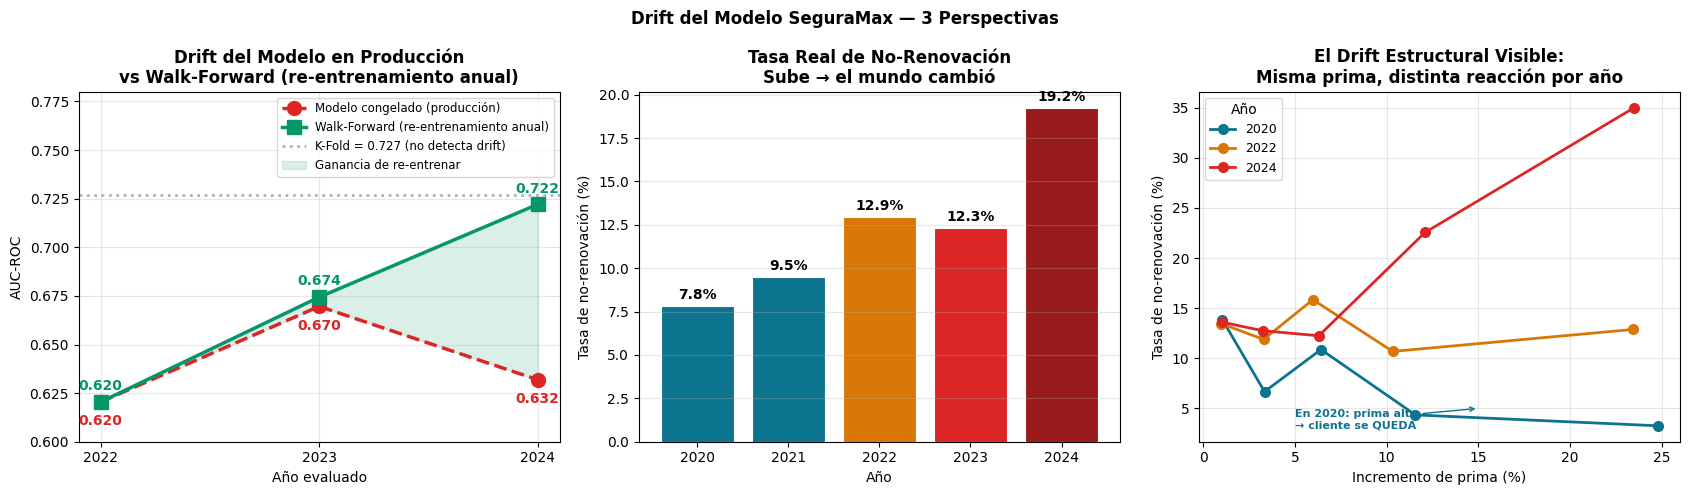

Panel 3 es el más importante: muestra el drift ESTRUCTURAL.
La misma variable (incremento_prima_pct) predice en dirección OPUESTA según el año.


In [6]:
# 🔧 COMPLETA: figura con 3 paneles
# Panel 1: AUC congelado (rojo punteado) vs Walk-Forward (verde) vs K-Fold (gris punteado)
# Panel 2: Tasa real de no-renovación por año (barras)
# Panel 3: Relación entre incremento_prima_pct y churn por año
#           (para 2020 y 2024: agrupa por quintiles de inc y muestra la tasa de no-renueva)
#           Este panel muestra visualmente el cambio de signo

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Drift del Modelo SeguraMax — 3 Perspectivas', fontweight='bold')

años_p      = [r['anio']          for r in resultados_wf]
aucs_wf_p   = [r['auc_wf']        for r in resultados_wf]
aucs_cong_p = [r['auc_congelado'] for r in resultados_wf]

# Panel 1
ax1 = axes[0]
# --- TU CÓDIGO AQUÍ ---

ax1.plot(años_p, aucs_cong_p, 'o--', color='#DC2626', lw=2.5, ms=10,
         label='Modelo congelado (producción)')
ax1.plot(años_p, aucs_wf_p, 's-', color='#059669', lw=2.5, ms=10,
         label='Walk-Forward (re-entrenamiento anual)')
ax1.axhline(scores.mean(), color='#94A3B8', lw=2, ls=':', alpha=0.8,
            label=f'K-Fold = {scores.mean():.3f} (no detecta drift)')
ax1.fill_between(años_p, aucs_cong_p, aucs_wf_p, alpha=0.15, color='#059669',
                 label='Ganancia de re-entrenar')
for a, v in zip(años_p, aucs_cong_p):
    ax1.text(a, v - 0.012, f'{v:.3f}', ha='center', fontsize=10,
             fontweight='bold', color='#DC2626')
for a, v in zip(años_p, aucs_wf_p):
    ax1.text(a, v + 0.006, f'{v:.3f}', ha='center', fontsize=10,
             fontweight='bold', color='#059669')
ax1.set_xlabel('Año evaluado'); ax1.set_ylabel('AUC-ROC')
ax1.set_title('Drift del Modelo en Producción\nvs Walk-Forward (re-entrenamiento anual)',
              fontweight='bold')
ax1.set_ylim(0.6, 0.78); ax1.set_xticks(años_p)
ax1.legend(fontsize=8.5); ax1.grid(True, alpha=0.3)


# Panel 2
ax2 = axes[1]
# --- TU CÓDIGO AQUÍ ---
tasa_nr = df.groupby('anio')['no_renueva'].mean() * 100
colores  = ['#0D7490','#0D7490','#D97706','#DC2626','#991B1B']
ax2.bar(tasa_nr.index, tasa_nr.values, color=colores, edgecolor='white', lw=0.8)
for a, v in tasa_nr.items():
    ax2.text(a, v + 0.4, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Año'); ax2.set_ylabel('Tasa de no-renovación (%)')
ax2.set_title('Tasa Real de No-Renovación\nSube → el mundo cambió', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: cambio de signo de la relación prima-churn
ax3= axes[2]
# Pista: para 2020 y 2024, agrupa por quintiles de inc y grafica la tasa de churn
# Para ver el drift: en 2020 la línea debería BAJAR, en 2024 debería SUBIR
# --- TU CÓDIGO AQUÍ ---
for anio, color in zip([2020, 2022, 2024], ['#0D7490','#D97706','#DC2626']):
    sub = df[df.anio==anio].copy()
    # Agrupar por deciles de incremento_prima_pct
    sub['decil'] = pd.qcut(sub['incremento_prima_pct'], q=5, duplicates='drop')
    gr = sub.groupby('decil', observed=True)['no_renueva'].mean() * 100
    centers = sub.groupby('decil', observed=True)['incremento_prima_pct'].mean()
    ax3.plot(centers.values, gr.values, 'o-', color=color, lw=2.0, ms=7, label=str(anio))
ax3.set_xlabel('Incremento de prima (%)')
ax3.set_ylabel('Tasa de no-renovación (%)')
ax3.set_title('El Drift Estructural Visible:\nMisma prima, distinta reacción por año',
              fontweight='bold')
ax3.legend(title='Año', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.annotate('En 2020: prima alta\n→ cliente se QUEDA',
             xy=(15, 5), xytext=(5, 3),
             arrowprops=dict(arrowstyle='->', color='#0D7490'),
             fontsize=8, color='#0D7490', fontweight='bold')
ax3.annotate('En 2024: prima alta\n→ cliente se VA',
             xy=(20, 40), xytext=(8, 45),
             arrowprops=dict(arrowstyle='->', color='#DC2626'),
             fontsize=8, color='#DC2626', fontweight='bold')

plt.tight_layout()
plt.savefig('ej1_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Panel 3 es el más importante: muestra el drift ESTRUCTURAL.")
print("La misma variable (incremento_prima_pct) predice en dirección OPUESTA según el año.")

---
## Parte 6 — Backtesting: ¿las decisiones del modelo fueron correctas en producción?

Hasta aquí evaluaste el modelo con métricas estáticas (AUC, Walk-Forward).
El **backtesting** hace algo diferente: toma el **modelo congelado que está en producción**,
lo aplica período a período sobre datos reales históricos, y mide si las decisiones
que habría tomado resultaron correctas cuando se reveló la realidad.

### La diferencia con lo que hiciste antes

| Lo que hiciste en Partes 3–4 | Backtesting (esta parte) |
|------------------------------|--------------------------|
| Compara AUC de congelado vs WF | El modelo es fijo: el congelado de producción |
| Usa años completos | Aplica el modelo **trimestre a trimestre** |
| Mide discriminación global | Mide aciertos/fallos **cuando se reveló la realidad** |
| No dice si las alertas fueron rentables | Calcula el **valor neto realizado** periodo a periodo |

### 🔧 6.1 — Backtesting trimestral del modelo congelado (2022–2024)

Simula que cada trimestre el modelo de SeguraMax generó alertas sobre las pólizas
que vencían ese período. Al final del trimestre, la realidad reveló quién sí se fue.
Mide si las alertas fueron correctas y cuánto valor generaron.

In [7]:
# 🔧 COMPLETA: backtesting trimestral del modelo congelado
#
# Para cada trimestre de 2022–2024:
#   1. Toma la cohorte de pólizas de ese trimestre (ya están asignadas)
#   2. Aplica el modelo CONGELADO (pipe_congelado) — el mismo siempre, sin re-entrenar
#   3. Genera alertas: y_alerta = (y_prob >= tau_c).astype(int)
#   4. Mide: VP, FP, FN, Precisión, Recall
#   5. Calcula el valor neto REALIZADO ese trimestre
#      valor_neto = round(VP * P_RET) * C_FN - (VP + FP) * C_FP
#   6. Guarda el Brier Score (calibración del modelo)
#      from sklearn.metrics import brier_score_loss
#      brier = brier_score_loss(y_real, y_prob)


from sklearn.metrics import brier_score_loss, roc_auc_score, confusion_matrix

# Asignación de trimestres (NO modificar — define las cohortes)
np.random.seed(42)
ANIOS_BT = [2022, 2023, 2024]
resultados_bt = []

for anio in ANIOS_BT:
    mask_año = df['anio'] == anio
    df_año = df[mask_año].copy()
    df_año['trimestre'] = np.random.choice(
        [1, 2, 3, 4],
        len(df_año),
        p=[.28, .26, .24, .22]
    )

    for q in [1, 2, 3, 4]:
        cohort = df_año[df_año['trimestre'] == q]

        if len(cohort) < 20:
            continue

        X_c = cohort[FEATURES].values
        y_real = cohort['no_renueva'].values

        # ── Modelo CONGELADO: NO se vuelve a entrenar ──
        y_prob = pipe_congelado.predict_proba(X_c)[:, 1]

        # ── Generar alertas usando el umbral por costos ──
        y_alerta = (y_prob >= tau_c).astype(int)

        if y_alerta.sum() == 0 or y_real.sum() == 0:
            continue

        # ── AUC ──
        auc = roc_auc_score(y_real, y_prob)

        # ── Matriz de confusión ──
        cm_ = confusion_matrix(y_real, y_alerta)
        vn_, fp_, fn_, vp_ = cm_.ravel()

        # ── Precisión y Recall ──
        prec = vp_ / (vp_ + fp_) if (vp_ + fp_) > 0 else 0
        rec = vp_ / (vp_ + fn_) if (vp_ + fn_) > 0 else 0

        # ── Brier Score ──
        brier = brier_score_loss(y_real, y_prob)

        # ── Valor neto ──
        retenidos = round(vp_ * P_RET)
        vnet = retenidos * C_FN - (vp_ + fp_) * C_FP

        # ── Score promedio ──
        score_pos = y_prob[y_real == 1].mean()
        score_neg = y_prob[y_real == 0].mean()

        resultados_bt.append({
            'periodo': f"{anio}-Q{q}",
            'anio': anio,
            'trimestre': q,
            'n': len(cohort),
            'alertas': y_alerta.sum(),
            'reales': y_real.sum(),
            'auc': auc,
            'brier': brier,
            'vp': vp_,
            'fp': fp_,
            'fn': fn_,
            'precision': prec,
            'recall': rec,
            'score_pos': score_pos,
            'score_neg': score_neg,
            'retenidos': retenidos,
            'vnet': vnet,
            'tasa_real': y_real.mean()
        })

df_bt = pd.DataFrame(resultados_bt)

print(f"Backtesting: {len(df_bt)} períodos evaluados (modelo fijo: congelado 2020–2021)")
print()

print(
    f"  {'Período':>10}  {'n':>5}  {'Alertas':>8}  {'VP':>4}  {'FP':>4}  "
    f"{'FN':>4}  {'Prec':>7}  {'Recall':>7}  {'AUC':>7}  {'Brier':>7}  "
    f"{'Valor neto':>12}"
)

print(f"  {'-'*95}")

for _, r in df_bt.iterrows():
    print(
        f"  {r['periodo']:>10}  {r['n']:>5,}  {r['alertas']:>8,}  "
        f"{r['vp']:>4}  {r['fp']:>4}  {r['fn']:>4}  "
        f"{r['precision']:>6.1%}  {r['recall']:>6.1%}  "
        f"{r['auc']:>7.3f}  {r['brier']:>7.4f}  "
        f"${r['vnet']:>10,.0f}"
    )

print()
print(f"Valor neto TOTAL acumulado: ${df_bt['vnet'].sum():,.0f}")
print(f"AUC promedio en producción: {df_bt['auc'].mean():.4f}")

Backtesting: 12 períodos evaluados (modelo fijo: congelado 2020–2021)

     Período      n   Alertas    VP    FP    FN     Prec   Recall      AUC    Brier    Valor neto
  -----------------------------------------------------------------------------------------------
     2022-Q1    141        64     7    57     7   10.9%   50.0%    0.504   0.1046  $    -3,200
     2022-Q2    126        65    17    48     4   26.2%   81.0%    0.735   0.1297  $    30,000
     2022-Q3    126        52     9    43     7   17.3%   56.2%    0.593   0.1372  $    12,800
     2022-Q4    117        53     9    44     6   17.0%   60.0%    0.606   0.1169  $    12,400
     2023-Q1    154        61    12    49     5   19.7%   70.6%    0.708   0.0954  $    20,400
     2023-Q2    122        48     6    42     5   12.5%   54.5%    0.622   0.0961  $     3,200
     2023-Q3    108        53    17    36     2   32.1%   89.5%    0.753   0.1481  $    34,800
     2023-Q4     96        40     6    34     6   15.0%   50.0%    0

### 🔧 6.2 — Visualización del backtesting período a período

Esta gráfica es el corazón del backtesting: muestra cómo se comportó el modelo
**real en producción**, trimestre a trimestre, desde 2022 hasta 2024.

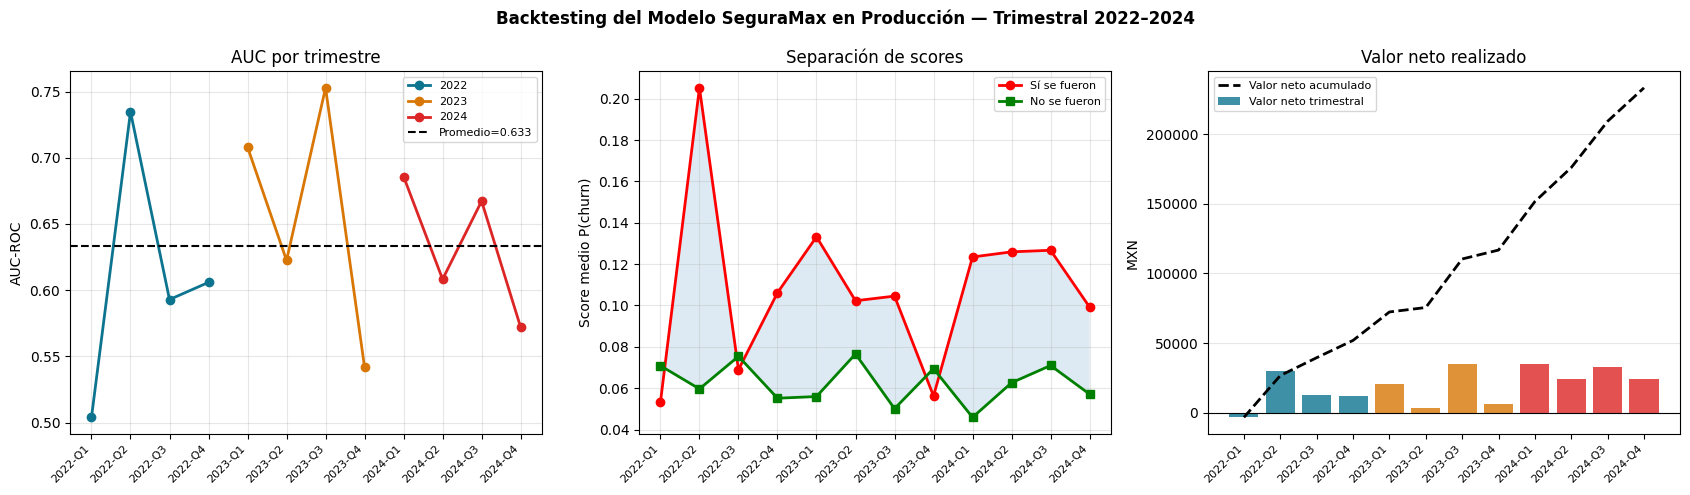

In [8]:
# Visualización del backtesting: 3 paneles

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Backtesting del Modelo SeguraMax en Producción — Trimestral 2022–2024',
             fontweight='bold')

periodos = df_bt['periodo'].tolist()
idx      = np.arange(len(periodos))
colores_anio = {'2022':'#0D7490','2023':'#D97706','2024':'#DC2626'}

# Panel 1: AUC por trimestre
ax = axes[0]
for anio, grp in df_bt.groupby('anio'):
    ax.plot(grp.index, grp['auc'], 'o-', lw=2,
            color=colores_anio[str(anio)], label=str(anio))
ax.axhline(df_bt['auc'].mean(), color='black', ls='--', lw=1.5,
           label=f"Promedio={df_bt['auc'].mean():.3f}")
ax.set_title('AUC por trimestre')
ax.set_ylabel('AUC-ROC')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Panel 2: separación de scores
ax = axes[1]
ax.plot(idx, df_bt['score_pos'], 'o-', color='red', lw=2,
        label='Sí se fueron')
ax.plot(idx, df_bt['score_neg'], 's-', color='green', lw=2,
        label='No se fueron')
ax.fill_between(idx, df_bt['score_neg'].values, df_bt['score_pos'].values,
                alpha=0.15)
ax.set_title('Separación de scores')
ax.set_ylabel('Score medio P(churn)')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Panel 3: valor neto por trimestre + acumulado
ax = axes[2]
colores_bar = [colores_anio[str(a)] for a in df_bt['anio']]
ax.bar(idx, df_bt['vnet'], color=colores_bar, alpha=0.8,
       label='Valor neto trimestral')
ax.plot(idx, df_bt['vnet'].cumsum(), 'k--', lw=2,
        label='Valor neto acumulado')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Valor neto realizado')
ax.set_ylabel('MXN')
ax.set_xticks(idx)
ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ej1_backtesting.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔧 6.3 — Diagnóstico del backtesting

Responde las siguientes preguntas con base en los resultados obtenidos.

In [9]:
# 🔧 DIAGNÓSTICO AUTOMÁTICO DEL BACKTESTING

print("=" * 60)
print("  DIAGNÓSTICO DEL BACKTESTING — Modelo SeguraMax")
print("=" * 60)

# 1. DEGRADACIÓN DEL AUC
auc_2022 = df_bt.loc[df_bt['anio'] == 2022, 'auc'].mean()
auc_2024 = df_bt.loc[df_bt['anio'] == 2024, 'auc'].mean()

cambio_auc = auc_2024 - auc_2022

print(f"\n1. DEGRADACIÓN DEL AUC:")
print(f"   AUC promedio 2022: {auc_2022:.4f}")
print(f"   AUC promedio 2024: {auc_2024:.4f}")
print(f"   Cambio: {cambio_auc:+.4f}")

if auc_2024 < auc_2022:
    print("   ⚠️ El AUC disminuyó: existe evidencia de degradación.")
else:
    print("   ✓ El AUC no disminuyó: la discriminación se mantiene.")

# 2. SEPARACIÓN DE SCORES
df_bt['separacion'] = df_bt['score_pos'] - df_bt['score_neg']

sep_2022 = df_bt.loc[
    df_bt['anio'] == 2022, 'separacion'
].mean()

sep_2024 = df_bt.loc[
    df_bt['anio'] == 2024, 'separacion'
].mean()

cambio_sep = sep_2024 - sep_2022

print(f"\n2. SEPARACIÓN DE SCORES (discriminación):")
print(f"   Separación 2022: {sep_2022:.4f}")
print(f"   Separación 2024: {sep_2024:.4f}")
print(f"   Cambio: {cambio_sep:+.4f}")

if sep_2024 < sep_2022:
    print("   ⚠️ La separación disminuyó: el modelo distingue peor.")
else:
    print("   ✓ La separación se mantiene o mejoró.")


# 3. VALOR NETO
vnet_total = df_bt['vnet'].sum()
trim_neg = (df_bt['vnet'] < 0).sum()

print(f"\n3. VALOR NETO REALIZADO:")
print(f"   Total acumulado: ${vnet_total:,.0f}")
print(f"   Trimestres con pérdida: {trim_neg}/{len(df_bt)}")

if trim_neg == 0:
    print("   ✓ El valor neto fue positivo en todos los trimestres.")
elif vnet_total > 0:
    print("   ⚠️ Hubo trimestres con pérdida, pero el resultado acumulado es positivo.")
else:
    print("   ❌ El valor neto acumulado es negativo.")


# 4. CALIBRACIÓN — BRIER SCORE
brier_2022 = df_bt.loc[
    df_bt['anio'] == 2022, 'brier'
].mean()

brier_2024 = df_bt.loc[
    df_bt['anio'] == 2024, 'brier'
].mean()

cambio_brier = brier_2024 - brier_2022

print(f"\n4. CALIBRACIÓN (Brier Score — menor = mejor):")
print(f"   Brier 2022: {brier_2022:.4f}")
print(f"   Brier 2024: {brier_2024:.4f}")
print(f"   Cambio: {cambio_brier:+.4f}")

if brier_2024 > brier_2022:
    print("   ⚠️ El Brier Score aumentó: la calibración empeoró.")
else:
    print("   ✓ La calibración se mantiene o mejoró.")


# RECOMENDACIÓN
print("\n" + "=" * 60)
print("RECOMENDACIÓN AL DIRECTOR DE RETENCIÓN")
print("=" * 60)

if auc_2024 < auc_2022 and sep_2024 < sep_2022:
    print(
        "⚠️ El modelo presenta señales de degradación. "
        "Se recomienda investigar el data drift y evaluar un "
        "reentrenamiento con información reciente."
    )
elif auc_2024 < auc_2022 or sep_2024 < sep_2022:
    print(
        "⚠️ Se observa deterioro en al menos una métrica. "
        "Se recomienda monitorear el modelo y analizar posibles "
        "cambios en los datos antes de reentrenarlo."
    )
else:
    print(
        "✓ El modelo mantiene un desempeño estable. "
        "Se recomienda continuar con el monitoreo periódico."
    )

  DIAGNÓSTICO DEL BACKTESTING — Modelo SeguraMax

1. DEGRADACIÓN DEL AUC:
   AUC promedio 2022: 0.6094
   AUC promedio 2024: 0.6333
   Cambio: +0.0240
   ✓ El AUC no disminuyó: la discriminación se mantiene.

2. SEPARACIÓN DE SCORES (discriminación):
   Separación 2022: 0.0431
   Separación 2024: 0.0597
   Cambio: +0.0165
   ✓ La separación se mantiene o mejoró.

3. VALOR NETO REALIZADO:
   Total acumulado: $233,200
   Trimestres con pérdida: 1/12
   ⚠️ Hubo trimestres con pérdida, pero el resultado acumulado es positivo.

4. CALIBRACIÓN (Brier Score — menor = mejor):
   Brier 2022: 0.1221
   Brier 2024: 0.1677
   Cambio: +0.0456
   ⚠️ El Brier Score aumentó: la calibración empeoró.

RECOMENDACIÓN AL DIRECTOR DE RETENCIÓN
✓ El modelo mantiene un desempeño estable. Se recomienda continuar con el monitoreo periódico.


<-- ---
## Parte 7 — Preguntas de reflexión y decisión final

### 📝 7.1

**a)** El Walk-Forward (Parte 4) y el backtesting (Parte 6) responden preguntas distintas.
¿Cuál es la diferencia entre "el modelo tiene AUC=0.72 en Walk-Forward 2024" y
"el modelo generó un AUC=0.68 en el backtesting del Q3-2024"?

> En el modelo Walk-forward 2024 estamos entrenando el modelo con toda la historia anterior de 2024 y poniendolo a prueba con lo que se observa en 2024, sin embargo en el backtesting entrenamos el modelo con el periodo de 2020-2021 y ponemos a prueba en cada trimestre a partir de 2022 hasta 2024.
> Por lo que el AUC de 0.72 del Walk Forward 2024 mide la capacidad general del modelo a lo largo de toto el año 2024 y el AUC 0.68 del backtesting mide el desempeño operativo real del modelo congelado en el tercer trimestre de 2024.

> El menor AUC en el backtesting refleja el efecto de drift, al no haberse actualizado desde 2021, el modelo congelado pierde capacidad discriminatoria frente a un modelo que sí aprende de la historia reciente.


---

**b)** El backtesting muestra que en ciertos trimestres el modelo tuvo Recall bajo
(no detectó muchos de los clientes que sí se fueron). ¿Qué le dirías al director
de Retención sobre los clientes que se fueron sin recibir llamada?
¿El modelo tiene la culpa o el umbral τ?

>  Al Director de Retención se le debe explicar que la estrategia de negocio ya era incluyente para capturar el riesgo (τ baja); sin embargo, debido al drift (la inversión de incremento_prima_pct), el modelo congelado asignó probabilidades de fuga casi nulas (menores al $3.4\%$) a clientes que realmente iban a cancelar

> Ambos influyen. El modelo puede no identificar correctamente a algunos clientes que finalmente se fueron, pero también depende del umbral τ utilizado para generar las alertas. Al ser un umbral muy bajo, el modelo debería generar más alertas; por lo tanto, si aun así el Recall es bajo en algunos trimestres, es necesario investigar también el desempeño del modelo y posibles cambios en los datos (drift).


---

**c)** El AUC del backtesting cae de 2022 a 2024 pero el valor neto acumulado
sigue siendo positivo. ¿Eso significa que el modelo no necesita re-entrenarse?
¿Qué criterio usarías para decidir cuándo re-entrenar?

> No necesariamente. Aunque el valor neto acumulado siga siendo positivo, si el AUC presenta una tendencia descendente significa que el modelo está perdiendo capacidad para discriminar correctamente entre los clientes que se van y los que permanecen. Si esta degradación se mantiene, sería recomendable re-entrenarlo. Para decidir cuándo hacerlo, consideraría una caída sostenida del AUC, un aumento del Brier Score, cambios en el Recall y una disminución del valor neto.


---

**d) BONUS — Ventana óptima de re-entrenamiento:**
Para predecir 2024, compara tres estrategias de train:
- Largo: 2020–2023 (todos los datos históricos)
- Reciente: 2022–2023 (solo los 2 últimos años)
- Último año: solo 2023

¿Cuál da el AUC más alto? ¿Cuál da el mayor valor neto? ¿Coinciden?

```python
# 🔧 BONUS
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24  = df.loc[mask_test_24, 'no_renueva'].values

for nombre, anios_tr in [
    ("Largo (2020-2023)",   [2020,2021,2022,2023]),
    ("Reciente (2022-2023)",[2022,2023]),
    ("Último año (2023)",   [2023]),
]:
    mask_tr = df['anio'].isin(anios_tr)
    # --- TU CÓDIGO AQUÍ ---
    # Entrena, predice, calcula AUC y valor neto
    pass
``` -->

**d) BONUS — Ventana óptima de re-entrenamiento:**
Para predecir 2024, compara tres estrategias de train:
- Largo: 2020–2023 (todos los datos históricos)
- Reciente: 2022–2023 (solo los 2 últimos años)
- Último año: solo 2023

¿Cuál da el AUC más alto? ¿Cuál da el mayor valor neto? ¿Coinciden?

In [30]:
mask_test_24 = df['anio'] == 2024
X_te24 = df.loc[mask_test_24, FEATURES].values
y_te24 = df.loc[mask_test_24, 'no_renueva'].values

resultados_bonus = []

print(f"  {'Ventana':<24} {'n train':>8} {'AUC':>8}  "
      f"{'Alertas':>8} {'TP':>5} {'FP':>5} {'FN':>5} {'Valor neto':>13}")

for nombre, anios_tr in [
    ("Largo (2020-2023)",   [2020, 2021, 2022, 2023]),
    ("Reciente (2022-2023)", [2022, 2023]),
    ("Último año (2023)",    [2023]),
]:
    mask_tr = df['anio'].isin(anios_tr)
    X_tr = df.loc[mask_tr, FEATURES].values
    y_tr = df.loc[mask_tr, 'no_renueva'].values

    pipe_bonus = Pipeline([
        ('sc', StandardScaler()),
        ('m', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                         learning_rate=0.08, random_state=2024))
    ])

    pipe_bonus.fit(X_tr, y_tr)
    yp_bonus = pipe_bonus.predict_proba(X_te24)[:, 1]
    y_pred_bonus = (yp_bonus >= tau_c).astype(int)

    auc_bonus = roc_auc_score(y_te24, yp_bonus)
    
    # Orden correcto de scikit-learn: TN, FP, FN, TP
    tn_, fp_, fn_, tp_ = confusion_matrix(y_te24, y_pred_bonus).ravel()
    
    retenidos = round(tp_ * P_RET)
    valor_neto_bonus = (retenidos * C_FN) - ((tp_ + fp_) * C_FP)

    resultados_bonus.append({
        'ventana': nombre,
        'n_train': len(y_tr),
        'auc': auc_bonus,
        'alertas': int(y_pred_bonus.sum()),
        'tp': int(tp_),
        'fp': int(fp_),
        'fn': int(fn_),
        'valor_neto': valor_neto_bonus
    })

    print(f"  {nombre:<24} {len(y_tr):>8,} {auc_bonus:>8.4f}  "
          f"{y_pred_bonus.sum():>8,} {tp_:>5} {fp_:>5} {fn_:>5} "
          f"${valor_neto_bonus:>11,.0f}")

bonus_df = pd.DataFrame(resultados_bonus)

mejor_auc = bonus_df.loc[bonus_df['auc'].idxmax()]
mejor_valor_neto = bonus_df.loc[bonus_df['valor_neto'].idxmax()]

print()
print()
print(f"Mayor AUC:         {mejor_auc['ventana']} ({mejor_auc['auc']:.4f})")
print(f"Mayor Valor Neto:  {mejor_valor_neto['ventana']} (${mejor_valor_neto['valor_neto']:,.0f})")
print()
print("¿Coinciden?: No.")
print("Conclusión: La ventana que da el AUC más alto es la Larga (2020-2023), pero la que da el mayor valor neto es la Reciente (2022-2023). \n"
"Esto ocurre porque la ventana Reciente elimina el ruido histórico de 2020-2021 (drift), capturando prácticamente los mismos clientes en riesgo (82 TP vs 83 TP) \n" 
"pero reduciendo 29 alertas inútiles (Falsos Positivos), lo que maximiza la rentabilidad operativa.")


  Ventana                   n train      AUC   Alertas    TP    FP    FN    Valor neto
  Largo (2020-2023)           1,945   0.7221       326    83   243    14 $    172,000
  Reciente (2022-2023)          990   0.7067       296    82   214    15 $    172,800
  Último año (2023)             480   0.7093       225    71   154    26 $    167,600


Mayor AUC:         Largo (2020-2023) (0.7221)
Mayor Valor Neto:  Reciente (2022-2023) ($172,800)

¿Coinciden?: No.
Conclusión: La ventana que da el AUC más alto es la Larga (2020-2023), pero la que da el mayor valor neto es la Reciente (2022-2023). 
Esto ocurre porque la ventana Reciente elimina el ruido histórico de 2020-2021 (drift), capturando prácticamente los mismos clientes en riesgo (82 TP vs 83 TP) 
pero reduciendo 29 alertas inútiles (Falsos Positivos), lo que maximiza la rentabilidad operativa.
